# Feature Selection en modelos de Machine Learning

La selección de características (feature selection) es un proceso fundamental dentro del flujo de trabajo en ciencia de datos y aprendizaje automático. Consiste en identificar y seleccionar un subconjunto relevante de variables de entrada que contribuyan de manera significativa a la predicción de la variable objetivo.

El uso de todas las variables disponibles no siempre es deseable. Entre los principales problemas asociados al uso indiscriminado de características se encuentran:

- **Sobreajuste (overfitting):** El modelo aprende patrones espurios presentes en los datos de entrenamiento.
- **Alta varianza:** Pequeñas variaciones en los datos pueden producir grandes cambios en el modelo.
- **Costo computacional elevado:** Especialmente relevante en datasets de gran dimensión.
- **Dificultad de interpretación:** Modelos con muchas variables son más difíciles de analizar.

En este laboratorio se estudiarán tres grandes enfoques de selección de características:

- **Métodos Filter:** Evalúan la relevancia de las variables de manera independiente del modelo.
- **Métodos Wrapper:** Utilizan un modelo para evaluar combinaciones de variables.
- **Métodos Embedded:** Integran la selección de características dentro del proceso de entrenamiento del modelo.

El laboratorio se divide en dos partes:

- Un bloque demostrativo con regresión lineal.
- Un bloque aplicado con regresión logística.

#### Imports

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
import kagglehub

## Demostración: Feature Selection en Regresión Lineal

En esta primera sección se trabajará con un enfoque demostrativo utilizando regresión lineal. El objetivo es comprender cómo distintos métodos de selección de características afectan el desempeño del modelo.

### Dataset

El dataset utilizado es el Auto MPG Dataset, ampliamente empleado en tareas de regresión.

Este conjunto de datos contiene información sobre automóviles de distintas épocas y su eficiencia de combustible, medida en millas por galón (miles per gallon, MPG). El objetivo es predecir esta variable en función de características técnicas del vehículo.

En este dataset, si bien se tienen variables que presentan relaciones lineales esperadas con la variable objetivo, existen también posibles correlaciones entre variables explicativas (multicolinealidad), lo cual es relevante para regresión lineal y necesita ser manejado para dar con un mejor desempeño del modelo.

In [2]:
url_dir = kagglehub.dataset_download("uciml/autompg-dataset")
file_name = "auto-mpg.csv"
url = os.path.join(url_dir, file_name)

df = pd.read_csv(url, na_values="?", comment="\t", sep=",", skipinitialspace=True)

df.head()

Using Colab cache for faster access to the 'autompg-dataset' dataset.


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [4]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


### Baseline

El baseline establece un punto de referencia utilizando todas las características disponibles, sin aplicar aún técnicas de selección. Esto permite cuantificar posteriormente si los métodos de feature selection efectivamente mejoran el desempeño del modelo.

#### Preprocesamiento

En esta etapa se preparan los datos para el entrenamiento del modelo. Esto incluye conversión de tipos de datos, manejo de valores faltantes y eliminación de variables no informativas

In [5]:
df_model = df.copy()

df_model = df_model.drop(columns=["car name"])

df_model = df_model.dropna()

df_model.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


**Pregunta 1:** ¿Por qué `car_name` no es una variable adecuada para un modelo de regresión lineal?

**Pregunta 2:** ¿Qué riesgos introduce eliminar filas con valores faltantes en lugar de imputarlos?

#### Ejecución del modelo base

Se entrena un modelo de regresión lineal utilizando todas las variables disponibles.

In [6]:
X = df_model.drop(columns=["mpg"])
y = df_model["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#### Evaluación con MSE y R²

Se utilizan dos métricas:

- MSE (Mean Squared Error)
- R² (coeficiente de determinación)

In [7]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R2: {r2:.3f}")

MSE: 10.71
R2: 0.790


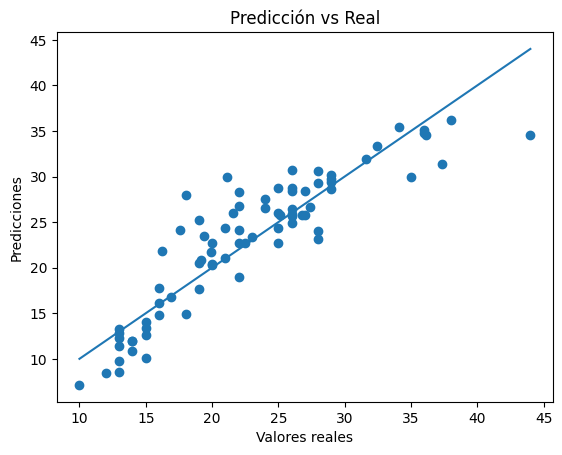

In [8]:
plt.scatter(y_test, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicción vs Real")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

**Pregunta 3:** ¿Qué indicaría un modelo perfecto en el gráfico anterior?

**Pregunta 4:** Si el modelo presentara un buen R² pero errores grandes en ciertos puntos, ¿qué sugeriría esto?

#### Evaluación con Cross-Validation

Esto permite obtener una estimación más robusta del desempeño del modelo.

In [9]:
mse_scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=5)
r2_scores = cross_val_score(model, X, y, scoring="r2", cv=5)

print("MSE (CV):", -mse_scores)
print("MSE promedio:", -mse_scores.mean())
print("R2 (CV):", r2_scores)
print("R2 promedio:", r2_scores.mean())

MSE (CV): [14.97430765 10.90595243  5.99170861 15.58754466 27.84474308]
MSE promedio: 15.060851285619856
R2 (CV): [0.55691895 0.68950582 0.82212138 0.6795006  0.2250594 ]
R2 promedio: 0.5946212315010343


**Pregunta 5:** ¿Por qué cross_val_score entrega valores negativos para el MSE?

**Pregunta 6:** ¿Qué indica una alta variabilidad en los resultados de validación cruzada?

**Pregunta 7:** Al comparar los resultados obtenidos en el conjunto de prueba con los resultados de validación cruzada, ¿qué conclusiones puedes extraer sobre la capacidad de generalización del modelo? ¿Cuál de estas evaluaciones puede considerarse más confiable?

### Métodos filter

Los métodos filter seleccionan características basándose en criterios estadísticos independientes del modelo predictivo. Cada variable es evaluada de forma individual respecto a la variable objetivo, sin considerar interacciones entre variables.

#### Método 1: Correlación

La correlación de Pearson mide la relación lineal entre dos variables. Su valor se encuentra en el rango [−1,1]:

- Valores cercanos a 1: relación lineal positiva fuerte
- Valores cercanos a -1: relación lineal negativa fuerte
- Valores cercanos a 0: ausencia de relación lineal

En el contexto de la selección de características, la correlación se puede utilizar con dos objetivos distintos:

- Evaluar la relación entre cada variable y la variable objetivo (relevancia)
- Evaluar la relación entre las propias variables (redundancia)

##### Correlación con la variable objetivo

Variables con mayor valor absoluto de correlación tienden a ser más informativas para predecir `mpg`. El signo indica la dirección de la relación (positiva o negativa), pero no su importancia relativa.

In [10]:
corr_with_target = df_model.corr()["mpg"].drop("mpg").sort_values(key=abs, ascending=False)
corr_with_target

,mpg
weight,-0.832244
displacement,-0.805127
horsepower,-0.778427
cylinders,-0.777618
model year,0.580541
origin,0.565209
acceleration,0.423329


##### Correlación entre variables (Multicolinealidad)

Hasta ahora se ha evaluado la relación de cada variable con la variable objetivo. Sin embargo, también es importante analizar la relación entre las propias variables explicativas.

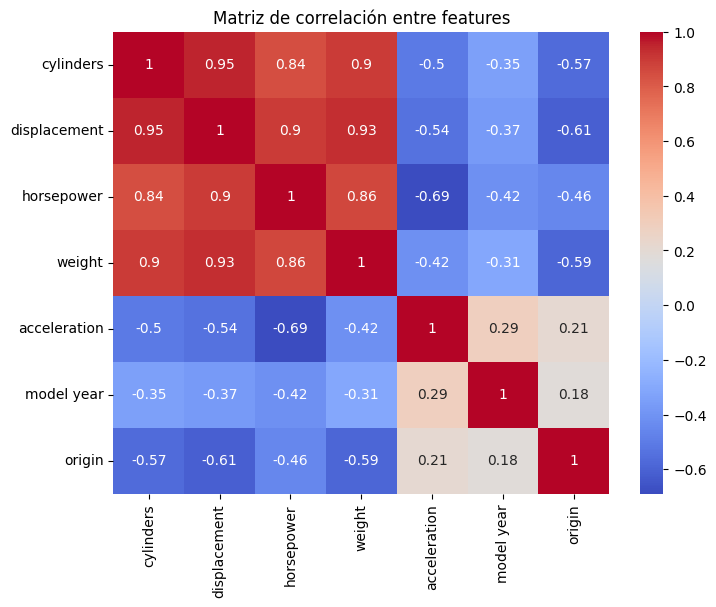

In [11]:
corr_matrix = X.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación entre features")
plt.show()

**Pregunta 8:** Si dos variables están altamente correlacionadas, ¿qué implicaciones tiene incluir ambas en el modelo?

**Pregunta 9:** ¿Cómo podría la multicolinealidad afectar los resultados obtenidos previamente en validación cruzada?

##### Selección basada en correlación

Una estrategia simple consiste en seleccionar variables con alta correlación con la variable objetivo a la vez que se evita incluir variables altamente correlacionadas entre sí.

El siguiente criterio permite reducir el número de variables según estas cruzan cierto umbral de correlación con el target, pero no elimina automáticamente la redundancia. Es posible que el subconjunto seleccionado contenga variables altamente correlacionadas entre sí.

In [12]:
threshold = 0.5

selected_features_corr = corr_with_target[abs(corr_with_target) > threshold].index.tolist()
selected_features_corr

['weight', 'displacement', 'horsepower', 'cylinders', 'model year', 'origin']

###### Evaluación sobre selección por correlación

In [13]:
mse_scores_corr = cross_val_score(LinearRegression(), X[selected_features_corr], y, scoring="neg_mean_squared_error", cv=5)
r2_scores_corr = cross_val_score(LinearRegression(), X[selected_features_corr], y, scoring="r2", cv=5)

print("MSE (CV):", -mse_scores_corr)
print("MSE promedio:", -mse_scores_corr.mean())
print("R2 (CV):", r2_scores_corr)
print("R2 promedio:", r2_scores_corr.mean())

MSE (CV): [15.19968966 10.6166618   5.89837955 15.39123034 27.22692615]
MSE promedio: 14.866577498895088
R2 (CV): [0.55025003 0.69774197 0.82489208 0.68353707 0.24225372]
R2 promedio: 0.5997349750886486


**Pregunta 10:** Después de reducir el número de variables según correlación, ¿cómo cambian los resultados? ¿Qué implica esto?

**Pregunta 11:** ¿Eliminar variables redundantes mejora siempre el modelo? Justifique.

##### Selección apoyada en multicolinealidad

**Ejercicio 1:** Identifique manualmente pares de variables altamente correlacionadas y proponga eliminar una de ellas. Luego, haga uso de Cross-Validation para evaluar si los resultados presentan mejora.

In [14]:
# Completar

**Pregunta 12:** Tras eliminar la variable redundante, ¿cómo cambian los resultados? ¿A qué podría deberse?

#### Método 2: f_regression

El método f_regression evalúa la relación lineal entre cada variable explicativa y la variable objetivo mediante un test estadístico F.

Este método es conceptualmente equivalente a la correlación, pero expresado en términos estadísticos: F-score mide la magnitud de la relación lineal, y p-value mide la significancia estadística.

En particular, variables con alta correlación suelen presentar alto F-score y bajo p-value. Sin embargo, al igual que la el método anterior, este evalúa cada variable de forma independiente, sin considerar interacción entre variables.

##### Cálculo de F-score y p-values

In [15]:
f_scores, p_values = f_regression(X, y)

f_results = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values(by="f_score", ascending=False)

f_results

,feature,f_score,p_value
3,weight,878.830886,6.015296e-102
1,displacement,718.677076,1.660642e-90
2,horsepower,599.717741,7.031989e-81
0,cylinders,596.564981,1.311384e-80
5,model year,198.259972,1.075794e-36
6,origin,183.075114,1.811080e-34
4,acceleration,85.150280,1.778576e-18


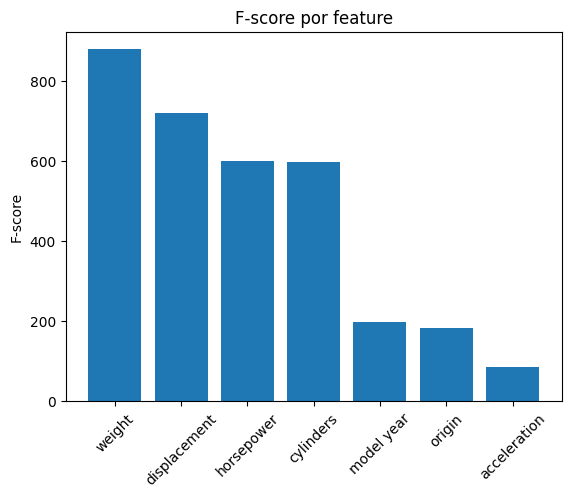

In [16]:
plt.bar(f_results["feature"], f_results["f_score"])
plt.xticks(rotation=45)
plt.title("F-score por feature")
plt.ylabel("F-score")
plt.show()

In [17]:
f_results.sort_values(by="p_value")

,feature,f_score,p_value
3,weight,878.830886,6.015296e-102
1,displacement,718.677076,1.660642e-90
2,horsepower,599.717741,7.031989e-81
0,cylinders,596.564981,1.311384e-80
5,model year,198.259972,1.075794e-36
6,origin,183.075114,1.811080e-34
4,acceleration,85.150280,1.778576e-18


**Pregunta 13:** ¿Observas correspondencia entre el ranking por correlación y por F-score? ¿Existen diferencias?

##### Selección de variables basada en F-score

In [18]:
k = 4
selected_features_f = f_results["feature"].iloc[:k].tolist()
selected_features_f

['weight', 'displacement', 'horsepower', 'cylinders']

##### Evaluación sobre selección por F-score

In [19]:
X_f = X[selected_features_f]

mse_scores_f = cross_val_score(LinearRegression(), X_f, y, scoring="neg_mean_squared_error", cv=5)

r2_scores_f = cross_val_score(LinearRegression(), X_f, y, scoring="r2", cv=5)

print("MSE (CV):", -mse_scores_f)
print("MSE promedio:", -mse_scores_f.mean())
print("R2 (CV):", r2_scores_f)
print("R2 promedio:", r2_scores_f.mean())

MSE (CV): [16.99909833 22.32204346  8.61428453 15.41251182 58.88247678]
MSE promedio: 24.4460829827569
R2 (CV): [ 0.49700658  0.36448792  0.74426376  0.68309949 -0.63874459]
R2 promedio: 0.33002263311317126


**Pregunta 14:** Tras seleccionar variables en función del F-score y evaluar el modelo, se observa un empeoramiento en las métricas. ¿Cómo se puede explicar este resultado?

#### Método 3: p-values con OLS

El método OLS es una técnica clásica para estimar los coeficientes de un modelo de regresión lineal, basada en la minimización del error cuadrático entre los valores reales y las predicciones. A diferencia de los métodos anteriores, OLS no solo permite ajustar un modelo, sino también analizar estadísticamente la relevancia de cada variable.

Mientras que la correlación y f_regression evalúan la relación entre cada variable y la variable objetivo de manera independiente, OLS evalúa la contribución de cada variable condicionada a la presencia de todas las demás. Esto introduce una diferencia fundamental: una variable puede parecer relevante de forma individual, pero dejar de ser significativa cuando se considera junto a otras.

Para entrenar el modelo OLS se requiere agregar explícitamente una constante para representar el intercepto del modelo. Sin él, el modelo quedaría restringido a pasar por el origen, lo cual no suele ser adecuado en la mayoría de los problemas reales.

In [20]:
import statsmodels.api as sm

# Agregar constante
X_ols = sm.add_constant(X)

model_ols = sm.OLS(y, X_ols).fit()

model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          2.04e-139
Time:                        15:23:32   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
model year       0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Pregunta 15:** Considerando el valor de R² y el resultado del test F, ¿qué se puede concluir sobre la calidad global del modelo OLS?

**Pregunta 16:** ¿Existen variables con alta correlación con mpg que no resultan significativas en OLS? ¿Cómo se explica esto?

**Pregunta 17:** ¿Qué indica el valor alto del Condition Number en el modelo?

**Pregunta 18:** ¿Por qué una variable puede ser relevante individualmente pero no significativa en un modelo multivariado?

##### Selección de variables basada en p-values

A partir de los p-values, es posible seleccionar un subconjunto de variables utilizando un umbral convencional, como 0.05. Es necesario entender que este umbral no es una regla estricta, sino una convención estadística, y su uso debe complementarse con evaluación empírica del modelo.


In [21]:
pvals = model_ols.pvalues.drop("const")

selected_features_ols = pvals[pvals < 0.05].index.tolist()
selected_features_ols

['displacement', 'weight', 'model year', 'origin']

##### Evaluación sobre selección por p-values

In [22]:
X_ols_selected = X[selected_features_ols]

mse_scores_ols = cross_val_score(LinearRegression(), X_ols_selected, y, scoring="neg_mean_squared_error", cv=5)

r2_scores_ols = cross_val_score(LinearRegression(), X_ols_selected, y, scoring="r2", cv=5)

print("MSE (CV):", -mse_scores_ols)
print("MSE promedio:", -mse_scores_ols.mean())
print("R2 (CV):", r2_scores_ols)
print("R2 promedio:", r2_scores_ols.mean())

MSE (CV): [13.36081753  9.99613452  5.75924204 15.90366498 27.80941288]
MSE promedio: 14.56585438889274
R2 (CV): [0.60466119 0.71540848 0.82902272 0.67300077 0.22604266]
R2 promedio: 0.6096271659203449


### Métodos wrapper

A diferencia de los métodos filter, los métodos wrapper seleccionan variables evaluando directamente el desempeño de un modelo predictivo. En lugar de analizar cada variable de forma independiente, estos métodos consideran combinaciones de variables y seleccionan aquellas que producen mejores resultados.

Esto permite abordar dos limitaciones observadas previamente: La selección basada en relaciones individuales y la la dificultad para interpretar variables en presencia de multicolinealidad.

En este enfoque, la selección de características se convierte en un problema de búsqueda: encontrar el subconjunto de variables que optimiza el desempeño del modelo.

#### Método 1: Forward Selection

Este método comienza con un modelo vacío e incorpora variables de forma iterativa, evaluando cada variable individualmente y agregando la que más mejore el modelo, repitiendo hasta que no haya mejora significativa.

In [23]:
model = LinearRegression()

sfs_forward = SequentialFeatureSelector(model, n_features_to_select=4, direction="forward", scoring="neg_mean_squared_error", cv=5)

sfs_forward.fit(X, y)

selected_features_forward = X.columns[sfs_forward.get_support()]
selected_features_forward

Index(['displacement', 'weight', 'model year', 'origin'], dtype='object')

In [24]:
X_forward = X[selected_features_forward]

mse_scores_forward = cross_val_score(model, X_forward, y, scoring="neg_mean_squared_error", cv=5)

r2_scores_forward = cross_val_score(model, X_forward, y, scoring="r2", cv=5)

print("MSE promedio (forward):", -mse_scores_forward.mean())
print("R2 promedio (forward):", r2_scores_forward.mean())

MSE promedio (forward): 14.56585438889274
R2 promedio (forward): 0.6096271659203449


**Pregunta 19:** ¿Qué variables fueron seleccionadas? ¿Coinciden con métodos anteriores?


**Pregunta 20:** ¿Mejora el desempeño respecto a los métodos filter?

#### Método 2: Backward Elimination

Este método comienza con todas las variables y elimina iterativamente las menos relevantes, priorizando la variable cuya eliminación menos perjudique el modelo y repitiendo hasta alcanzar el número deseado.

Existen dos variantes del método backward:

- Una versión clásica basada en p-values, propia del enfoque estadístico
- Una versión moderna (sequential backward selection), que utiliza métricas de desempeño y validación cruzada

En este laboratorio se utilizará la segunda, ya que está alineada con el objetivo de optimizar la capacidad predictiva del modelo.

In [25]:
sfs_backward = SequentialFeatureSelector(model, n_features_to_select=4, direction="backward", scoring="neg_mean_squared_error", cv=5)

sfs_backward.fit(X, y)

selected_features_backward = X.columns[sfs_backward.get_support()]
selected_features_backward

Index(['displacement', 'weight', 'model year', 'origin'], dtype='object')

In [26]:
X_backward = X[selected_features_backward]

mse_scores_backward = cross_val_score(model, X_backward, y, scoring="neg_mean_squared_error", cv=5)

r2_scores_backward = cross_val_score(model, X_backward, y, scoring="r2", cv=5)

print("MSE promedio (backward):", -mse_scores_backward.mean())
print("R2 promedio (backward):", r2_scores_backward.mean())

MSE promedio (backward): 14.56585438889274
R2 promedio (backward): 0.6096271659203449


**Pregunta 21:** ¿Existen diferencias entre forward y backward? ¿Por qué podrían ocurrir?


#### Método 3: Recursive Feature Elimination (RFE)

RFE elimina variables de forma iterativa basándose en la importancia de los coeficientes del modelo. Para esto, se entrena el modelo con todas las variables y se elimina la variable menos importante, para luego reentrenar y repetir hasta alcanzar el número deseado.

In [27]:
rfe = RFE(model, n_features_to_select=4)
rfe.fit(X, y)

selected_features_rfe = X.columns[rfe.support_]
selected_features_rfe

Index(['cylinders', 'acceleration', 'model year', 'origin'], dtype='object')

In [28]:
X_rfe = X[selected_features_rfe]

mse_scores_rfe = cross_val_score(model, X_rfe, y, scoring="neg_mean_squared_error", cv=5)

r2_scores_rfe = cross_val_score(model, X_rfe, y, scoring="r2", cv=5)

print("MSE promedio (RFE):", -mse_scores_rfe.mean())
print("R2 promedio (RFE):", r2_scores_rfe.mean())

MSE promedio (RFE): 20.12786658753489
R2 promedio (RFE): 0.460872872750388


**Pregunta 22:** ¿En qué se diferencia RFE de forward/backward?


#### Método 4: Stepwise Selection

Por último, el método stepwise combina forward y backward dinámicamente: Agrega variables que mejoran el modelo y elimina variables que dejan de ser útiles.

Scikit-learn no incluye una implementación directa, pero conceptualmente el proceso consiste en comenzar como forward, evaluando la eliminación de variables después de cada incorporación, y repitiendo hasta la convergencia.

In [29]:
def stepwise_selection(X, y, threshold_in=0.01, threshold_out=0.01, verbose=True):
    included = []
    model = LinearRegression()

    while True:
        changed = False

        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_scores = {}

        for new_col in excluded:
            features = included + [new_col]
            score = -cross_val_score(
                model, X[features], y,
                scoring="neg_mean_squared_error", cv=5
            ).mean()
            new_scores[new_col] = score

        if new_scores:
            best_feature = min(new_scores, key=new_scores.get)
            best_score = new_scores[best_feature]

            current_score = np.inf
            if included:
                current_score = -cross_val_score(
                    model, X[included], y,
                    scoring="neg_mean_squared_error", cv=5
                ).mean()

            if best_score < current_score:
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f"Agregar: {best_feature}, MSE: {best_score:.3f}")

        # Backward step
        if included:
            scores = {}
            for col in included:
                features = list(set(included) - {col})
                if not features:
                    continue
                score = -cross_val_score(
                    model, X[features], y,
                    scoring="neg_mean_squared_error", cv=5
                ).mean()
                scores[col] = score

            # Added check for empty scores dictionary
            if scores:
                worst_feature = min(scores, key=scores.get)
                worst_score = scores[worst_feature]

                current_score = -cross_val_score(
                    model, X[included], y,
                    scoring="neg_mean_squared_error", cv=5
                ).mean()

                if worst_score < current_score:
                    included.remove(worst_feature)
                    changed = True
                    if verbose:
                        print(f"Eliminar: {worst_feature}, MSE: {worst_score:.3f}")

        if not changed:
            break

    return included

In [ ]:
selected_features_stepwise = stepwise_selection(X, y)
selected_features_stepwise

Agregar: weight, MSE: 25.023
Agregar: model year, MSE: 15.211
Agregar: origin, MSE: 14.645
Agregar: displacement, MSE: 14.566
Agregar: cylinders, MSE: 14.353


In [ ]:
X_stepwise = X[selected_features_stepwise]

mse_scores_stepwise = cross_val_score(LinearRegression(), X_stepwise, y, scoring="neg_mean_squared_error", cv=5)

r2_scores_stepwise = cross_val_score(LinearRegression(), X_stepwise, y, scoring="r2", cv=5)

print("MSE promedio (stepwise):", -mse_scores_stepwise.mean())
print("R2 promedio (stepwise):", r2_scores_stepwise.mean())

**Pregunta 23:** ¿Qué ventaja podría tener stepwise frente a forward o backward?

### Métodos embedded

Los métodos embedded integran la selección de características directamente dentro del proceso de entrenamiento del modelo. A diferencia de los métodos filter y wrapper, no separan la selección de variables del ajuste del modelo, sino que ambos procesos ocurren simultáneamente. En este enfoque, el modelo incorpora mecanismos que penalizan la complejidad, lo que permite reducir la influencia de variables irrelevantes o redundantes.

Los métodos más representativos de este enfoque son aquellos basados en regularización, que consisten en añadir un término de penalización a la función de costo del modelo. En el caso de la regresión lineal, la función objetivo pasa de minimizar únicamente el error a considerar también la magnitud de los coeficientes, permitiendo reducir el sobreajuste, controlar la complejidad del modelo y disminuir el impacto de variables poco relevantes.

En este laboratorio, exploramos los métodos embedded Ridge y Lasso, basados en regularización.

#### Método 1: Ridge (L2)

La regresión Ridge añade una penalización basada en la suma de los cuadrados de los coeficientes:

$$
\text{Loss} = \text{MSE} + \alpha \sum_{j=1}^{p} \beta_j^2
$$

De esta manera, se penaliza a los coeficientes grandes, reduciendo su magnitud pero sin eliminarlos completamente. Este enfoque es útil cuando existe multicolinealidad.

In [ ]:
lr = LinearRegression()
lr.fit(X, y)

coeffs_lr = pd.Series(lr.coef_, index=X.columns)
coeffs_lr

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X, y)

coeffs_ridge = pd.Series(ridge.coef_, index=X.columns)
coeffs_ridge.sort_values()

In [ ]:
mse_scores_ridge = cross_val_score(ridge, X, y, scoring="neg_mean_squared_error", cv=5)

r2_scores_ridge = cross_val_score(ridge, X, y, scoring="r2", cv=5)

print("MSE promedio (Ridge):", -mse_scores_ridge.mean())
print("R2 promedio (Ridge):", r2_scores_ridge.mean())

**Pregunta 24:** ¿Cómo cambian los coeficientes respecto a la regresión lineal sin regularización?

#### Método 2: Lasso (L1)

La regresión Lasso utiliza una penalización basada en la suma de los valores absolutos de los coeficientes:

$$
\text{Loss} = \text{MSE} + \alpha \sum_{j=1}^{p} |\beta_j|
$$

Este enfoque también penaliza aun más fuertemente a los coeficientes grandes, teniendo la capacidad para llevar algunos coeficientes exactamente a cero para efectivamente eliminarlos. De esta manera, se realiza selección de variables de forma automática.

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X, y)

coeffs_lasso = pd.Series(lasso.coef_, index=X.columns)
coeffs_lasso.sort_values()

In [ ]:
mse_scores_lasso = cross_val_score(lasso, X, y, scoring="neg_mean_squared_error", cv=5)

r2_scores_lasso = cross_val_score(lasso, X, y, scoring="r2", cv=5)

print("MSE promedio (Lasso):", -mse_scores_lasso.mean())
print("R2 promedio (Lasso):", r2_scores_lasso.mean())

**Pregunta 25:** ¿Qué variables fueron eliminadas por Lasso? ¿Coinciden con métodos anteriores?


**Pregunta 26:** ¿Cómo se comparan los resultados de Lasso con los métodos wrapper?

#### Hiperparámetro α

En los métodos de regularización, el hiperparámetro α controla la intensidad de la penalización aplicada a los coeficientes del modelo. A medida que aumenta α:

- En Ridge, los coeficientes se reducen progresivamente hacia cero.
- En Lasso, algunos coeficientes pueden volverse exactamente cero.

Es la magnitud de α lo que convierte a Lasso en un método de selección de variables.

##### Experimento: Búsqueda de α con GridSearchCV

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {"alpha": alphas}

grid_ridge = GridSearchCV(
    ridge,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

grid_ridge.fit(X, y)

best_ridge = grid_ridge.best_estimator_

print("Mejor alpha (Ridge):", grid_ridge.best_params_)
print("Mejor MSE (Ridge):", -grid_ridge.best_score_)

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

grid_lasso = GridSearchCV(
    lasso,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

grid_lasso.fit(X, y)

best_lasso = grid_lasso.best_estimator_

print("Mejor alpha (Lasso):", grid_lasso.best_params_)
print("Mejor MSE (Lasso):", -grid_lasso.best_score_)

In [ ]:
from sklearn.model_selection import cross_val_score

# Ridge
mse_ridge = -cross_val_score(
    best_ridge, X, y,
    scoring="neg_mean_squared_error", cv=5
).mean()

r2_ridge = cross_val_score(
    best_ridge, X, y,
    scoring="r2", cv=5
).mean()

# Lasso
mse_lasso = -cross_val_score(
    best_lasso, X, y,
    scoring="neg_mean_squared_error", cv=5
).mean()

r2_lasso = cross_val_score(
    best_lasso, X, y,
    scoring="r2", cv=5
).mean()

print("Ridge - MSE:", mse_ridge, "R2:", r2_ridge)
print("Lasso - MSE:", mse_lasso, "R2:", r2_lasso)

In [ ]:
results = pd.DataFrame(grid_ridge.cv_results_)
results[["param_alpha", "mean_test_score"]]

**Pregunta 27:** ¿Cómo cambia el valor óptimo de α respecto a los valores evaluados?

**Pregunta 28:** ¿El valor óptimo de α es el mismo para Ridge y Lasso? ¿Por qué podría diferir?

## Aplicación: Feature Selection en Regresión Logística

En este bloque se presenta un caso práctico donde el objetivo no es replicar todos los métodos vistos previamente, sino seleccionar, aplicar y justificar un enfoque de feature selection.

A diferencia del bloque anterior, aquí no se indicará explícitamente qué métodos utilizar. En su lugar, se espera que el estudiante:

- Analice el dataset
- Identifique posibles problemas (redundancia, multicolinealidad, etc.)
- Seleccione métodos adecuados
- Justifique sus decisiones
- Evalúe los resultados obtenidos

### Dataset

Este dataset es ampliamente utilizado en problemas de clasificación binaria. El objetivo es predecir si un tumor es Maligno (0) o Benigno (1) a partir de características calculadas a través del análisis de imágenes digitalizadas de biopsias.

Existen 30 variables numéricas, incluyen medidas como radio, textura, perímetro, área o suavidad. Muchas variables derivan de las mismas mediciones. Esto sugiere la posible presencia de redundancia, multicolinealidad y variables altamente correlacionadas.

In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()

### Parte 1: Análisis exploratorio

Antes de aplicar cualquier método, es fundamental comprender la estructura del dataset. Para esto, revise la forma del dataset, identifique el número de variables, analice si existen valores faltantes, y aborde cualquier otro elemento relevante para el caso. Observa la correlación de las variables con el target y entre sí mismas para entender la naturaleza del problema.

### Parte 2: Definición de estrategia

Con base en el análisis previo, selecciona 2 o 3 métodos de feature selection entre los vistos en el laboratorio, justificando su elección. No es necesario aplicar todos los métodos. Se evaluará la justificación y coherencia de la elección.

### Parte 3: Baseline

Antes de aplicar feature selection, entrena un modelo base. Evalúa las métricas que consideres más apropiadas dado el caso. Tras obtener los resultados, determina si estos son suficientes y qué problemas subyacentes podrían existir.

### Parte 4: Feature Selection

Aplica los métodos seleccionados y entrena nuevos modelos utilizando únicamente las variables seleccionadas. Para cada método, selecciona variables, entrena el modelo y evalúa mediante validación cruzada.

### Parte 5: Discusión final

Analiza los resultados considerando preguntas clave tales como:

- ¿Cómo cambian los resultados respecto al baseline?
- ¿Se reduce el número de variables? ¿Qué implica esto?
- ¿Los métodos utilizados producen subconjuntos similares o distintos?
- Si los resultados no mejoran, ¿significa que el feature selection fue incorrecto? Justifique.